Con este documento pretendo explicar algunos conceptos sobre gestión de carteras que espero te puedan ayudar.

In [58]:
#Empiezo cargando librerías necesarias para la parte de programación.
! pip install yfinance
! pip install cvxpy
! pip install seaborn
! pip install spicy

In [59]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Empezamos con tres piezas importantes del puzzle.

Vamos a suponer que tenemos unos activos en los que podemos nvertir, éstos son los "universe_tickers", una selección de 51 activos que recogen todos los sectores del SP500.

Luego tenemos una selección de esos activos, en la que he llamado "portfolio_tickers" que serán los activos de nuestra cartera.

Por último, tengo los pesos. Los pesos son el porcentaje de inversión que detino a cada activo. Por ejemplo, en Netflix invierto un 5.56% o en META un 13.49%. Estos números los he generado aleatoriamente,más tarde veremos qué porcentaje de nversión puedo destinar a cada activo para poder optimizar el menor riesgo o la máxima rentabilidad. Cabe mencionar, que la suma de éstos pesos siempre debe sumar 1 (100%), porque si tú tienes 500€ para invertir, sólo vas a poder invertir sa cifra, es decir, vas a tener que repartir esos 500€ entre los distintos activos. Aquí se expresa en porcentajes.

In [60]:
universe_tickers = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NVDA', 'JPM', 'UNH', 'PG',
    'XOM', 'CVX', 'HD', 'DIS', 'MA', 'V', 'BAC', 'PEP', 'KO', 'NFLX', 'INTC',
    'CSCO', 'WMT', 'SPY', 'GLD', 'TLT', 'SHY', 'BND', 'VNQ', 'TIP', 'AGG', 'IAU',
    'MUB', 'VEA', 'VTIP', 'IVV', 'VTI', 'BIL', 'ARKK', 'EFA', 'IWM', 'FXI',
    'EWJ', 'EWZ', 'LQD', 'HYG', 'USO', 'SLV', 'XLU', 'XLF', 'XLK'
]

portfolio_tickers = ['IWM', 'AGG', 'EWZ', 'NFLX', 'TSLA', 'XLU', 'META', 'ARKK', 'XLK', 'IAU']

portfolio_weights = [0.0714, 0.1349, 0.17, 0.0556, 0.0839, 0.0556, 0.1349, 0.1270, 0.0873, 0.0794]

En estas líneas de código tomo una fecha de inicio y una fecha final. Estas fechas nos sirven para hacer una especie de estimación histórica de cuánto podemos llegar a ganar con los activos elegidos.

In [61]:
start_d= '2020-01-01'
end_d= '2024-12-31'
datos_universe = yf.download(universe_tickers, start=start_d, end=end_d,auto_adjust=False)['Adj Close']

[*********************100%***********************]  51 of 51 completed


¿Qué es Adj Close y por qué lo escojo?

El “adjusted close” o cierre ajustado es el precio final de una acción en la bolsa, pero corregido para reflejar los cambios que se producen por los dividendos y los splits de las acciones.

Explicación sencilla
El precio de cierre normal es simplemente cuánto valía una acción al cierre del mercado cada día, pero en ocasiones ocurren dos cosas importantes:

Dividendo: Cuando una empresa reparte dinero entre sus accionistas, ese valor no se refleja en el precio de cierre sin ajustar, pero sí en el ajustado. Es como si para poder comparar el valor real de la acción día a día, se tuviera en cuenta el dinero que te “dieron” por tener la acción.

Split (división): A veces, una empresa divide cada acción en varias nuevas (por ejemplo, 1 pasa a ser 2, y el precio de cada una se reduce a la mitad). El precio ajustado tiene en cuenta este cambio, para que al mirar el pasado, los valores sean comparables, como si siempre hubieran existido la misma cantidad de acciones.

¿Por qué es importante?
El “adjusted close” sirve para comparar realmente cuánto ha subido o bajado una acción teniendo en cuenta los beneficios que recibiste por tenerla (dividendos) y los cambios en la cantidad de acciones (splits).

Es la forma más justa de ver cómo habría cambiado tu inversión con el paso del tiempo sin que te afecten esos eventos especiales.

Ejemplo concreto
Si una acción costaba 100 y da un dividendo de 2, el precio ajustado (al día siguiente) sería como si el precio fuera de 98, porque el valor real incluye el dinero recibido. Si después hace un split y ahora tienes el doble de acciones pero cada una vale la mitad, el precio ajustado recalcula todo para que sigas comparando bien.

Así, el “adjusted close” muestra el valor real teniendo en cuenta los cambios a lo largo del tiempo, como si siempre estuviera todo en las mismas condiciones.

Vamos a empezar a jugar un poco con los datos. Vamos a averiguar qué activo es el más rentable y cuál es menos volatil.
Para ello tomo todos los activos del saco de los 51.

In [62]:
retornos_log_universe= np.log(datos_universe).diff().dropna()
rentabilidad_universe= retornos_log_universe.mean()*252
volatilidad_universe= retornos_log_universe.std()*np.sqrt(252)

print(f'La mayor rentabilidad es:',round(max(rentabilidad_universe*100),4), '%. La compañía es:', rentabilidad_universe.idxmax(), 'eso sí, a un riesgo de:', round(volatilidad_universe[rentabilidad_universe.idxmax()]*100, 4),'%')
print(f'La menor volatilidad es de:',round(min(volatilidad_universe*100),4), '%. La compañía es:', volatilidad_universe.idxmin(), ', pero ofrece una rentabilidad de tan sólo:', round(rentabilidad_universe[volatilidad_universe.idxmin()]*100, 4),'%')
print()
print('A tener en cuenta: Un bono del Estado obrece a 3 años: cerca del 2,2% anual y a 5 años ronda el 2,5%')
print('Importante: La inflación en 2024 fue del 2,8, en 2023 del 3,1, es decir, la rentabilidad debería anualmente superar esos valores. ¡Qué menos!')

La mayor rentabilidad es: 62.9268 %. La compañía es: NVDA eso sí, a un riesgo de: 53.5254 %
La menor volatilidad es de: 0.2658 %. La compañía es: BIL , pero ofrece una rentabilidad de tan sólo: 2.3131 %

A tener en cuenta: Un bono del Estado obrece a 3 años: cerca del 2,2% anual y a 5 años ronda el 2,5%
Importante: La inflación en 2024 fue del 2,8, en 2023 del 3,1, es decir, la rentabilidad debería anualmente superar esos valores. ¡Qué menos!


Como puedes ver los activos que son más rentables tienden a ser más volátiles. La explicación es sencilla que fue lo que explicaba el otro día: Las empresas que son financieramente más volátiles suelen ofrecer una rentabilidad mayor porque el mercado exige una **prima de riesgo** más alta para compensar a los inversores por la mayor incertidumbre y riesgo asumido. La volatilidad mide qué tanto pueden variar los precios o rendimientos del activo, y una mayor volatilidad implica mayor riesgo de resultados extremos o inesperados.

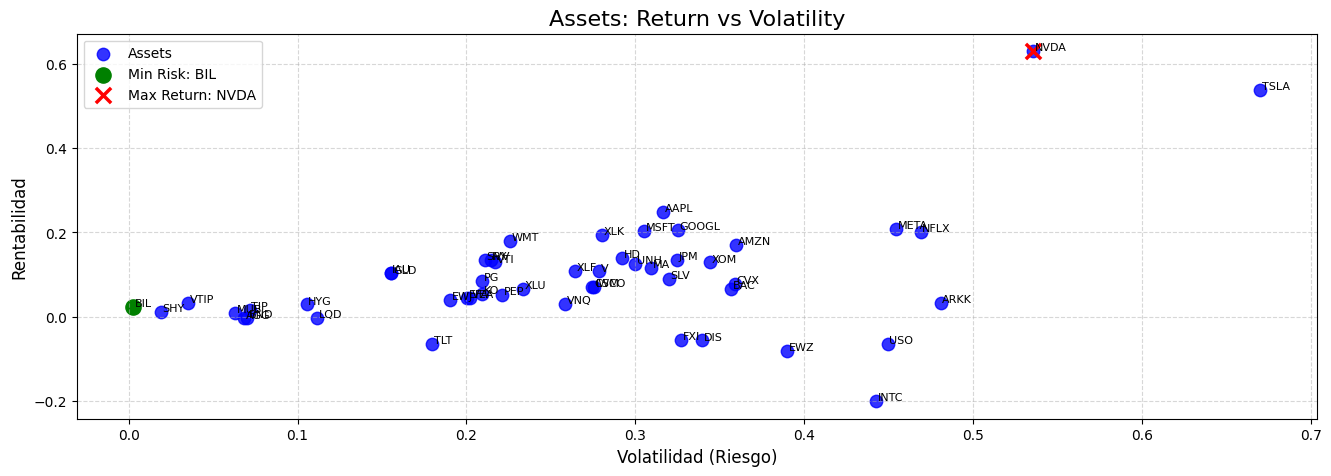

In [63]:
plt.figure(figsize=(16,5))

# Puntos de los activos
plt.scatter(volatilidad_universe, rentabilidad_universe, color='blue', s=80, alpha=0.8, label="Assets")

# Añadir etiquetas de cada activo
for asset in volatilidad_universe.index:
    plt.text(volatilidad_universe[asset] + 0.001,
             rentabilidad_universe[asset] + 0.001,
             asset, fontsize=8)

# Activo de menor riesgo
min_vol = volatilidad_universe.min()
asset_min_vol = volatilidad_universe.idxmin()
plt.scatter(min_vol, rentabilidad_universe[asset_min_vol], color='green', s=120, marker='o', label=f'Min Risk: {asset_min_vol}')

# Activo más rentable
max_ret = rentabilidad_universe.max()
asset_max_ret = rentabilidad_universe.idxmax()
plt.scatter(volatilidad_universe[asset_max_ret], max_ret, color='red', s=120, marker='x', linewidths=2.5, label=f'Max Return: {asset_max_ret}')

# Etiquetas y estilo
plt.title('Assets: Return vs Volatility', fontsize=16)
plt.xlabel('Volatilidad (Riesgo)', fontsize=12)
plt.ylabel('Rentabilidad', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Aquí represento la relación entre volatilidad (riesgo) y rentabilidad esperada de todos los activos que componen universe_tickers. En el gráfico he señalado en verde el activo con menor volatilidad y en rojo el activo con mayor rentabilidad, de acuerdo con el cálculo realizado previamente.

Lo primero que llama la atención es que no siempre tiene sentido invertir en un activo de forma aislada. Por ejemplo, TESLA presenta una elevada volatilidad sin que su rentabilidad compense adecuadamente ese riesgo. Comparativamente, NVIDIA, aun siendo también un activo muy volátil, ofrece mayor rentabilidad con un nivel de riesgo similar o incluso menor, lo que la hace relativamente más atractiva que TESLA.

Este patrón se repite en distintos puntos de la nube: siempre resulta más razonable elegir activos que ofrezcan mejor combinación de riesgo y retorno. Por ejemplo, sería poco eficiente invertir en NTC, que combina baja rentabilidad y alto riesgo, cuando existe una alternativa como AAPL (Apple) que proporciona una rentabilidad significativamente mayor con menor riesgo.

##Segunda Parte

En esta segunda parte hago lo mismo -de momento- pero con los activos de los de la cartera que hemos elegido para un posible cliente.
La mayoría de éstos son ETFs que representan diferentes sectores o tipos de activos (renta variable pequeña capitalización, bonos, emergentes, sector o tecnología), junto con algunas acciones individuales de tecnología/consumo.

In [64]:
start_d= '2020-01-01'
end_d= '2024-12-31'
datos_portfolio = yf.download(portfolio_tickers, start=start_d, end=end_d,auto_adjust=False)['Adj Close']

[*********************100%***********************]  10 of 10 completed


In [65]:
retornos_log_cartera=np.log(datos_portfolio).diff().dropna() #logaritmizamos los retornos
rentabilidad_cartera_activos= retornos_log_cartera.mean() #calculamos la rentabilidad de los 10 activos de la cartera calculando la media de los retornos.
#Si imprimimos 'rentabilidad_cartera_activos' nos saldrá la rentabilidad de cada uno de los activos NO DE LA CARTERA.
volatilidad_cartera_activos= retornos_log_cartera.std() #y la volatilidad de esos activos, caculando la varianza de la cartera.
matriz_cov= retornos_log_cartera.cov() #la matriz de covarianzas la saco para calculos posteriores con los pesos.
pesos=np.array(portfolio_weights)

In [66]:
rentabilidad_cartera_activos

,0
Ticker,
AGG,-0.000015
ARKK,0.000131
EWZ,-0.000318
IAU,0.000415
IWM,0.000279
META,0.000828
NFLX,0.000800
TSLA,0.002132
XLK,0.000769


In [67]:
retornos_cartera=np.array(retornos_log_cartera) @ pesos
rentabilidad_cartera= retornos_cartera.mean() #calculamos la rentabilidad de la cartera diaria. AHORA SÍ.
volatilidad_cartera= np.sqrt(pesos @ matriz_cov @ pesos.T) #y la volatilidad
rentabilidad_cartera_anual= retornos_cartera.mean()*252 #ANUALIZO LA RENTABILIDAD
volatilidad_cartera_anual= np.sqrt(pesos @ matriz_cov*252 @ pesos.T) #ANUALIZO EL RIESGO

In [68]:
print('Annual return:', round(rentabilidad_cartera_anual,4)*100,'%')
print('Annual volatility:', round(volatilidad_cartera_anual,2)*100,'%')

Annual return: 13.15 %
Annual volatility: 27.0 %


##Tercera Parte

Vamos a sacar tres estadísticas importantes. La primera es saber cuánto se puede perder en un día según el histórico.

Si el VaR es -0.32, significa que con alta probabilidad la pérdida no debería superar el 32% en un solo día, lo que indica un alto riesgo o volatilidad en la cartera. Hay un 95% de probabilidad de que la pérdida diaria no supere el 32%, pero un 5% de probabilidad de que la pérdida sea mayor

In [69]:
# Estimación de la máxima pérdida diaria con un 95% de confianza.
from scipy.stats import norm
mean=rentabilidad_cartera_anual
std=volatilidad_cartera_anual
max_95=mean+norm.ppf(0.05)*std
print(f'Max loss for 95% confidence:',round(max_95,4))

Max loss for 95% confidence: -0.32


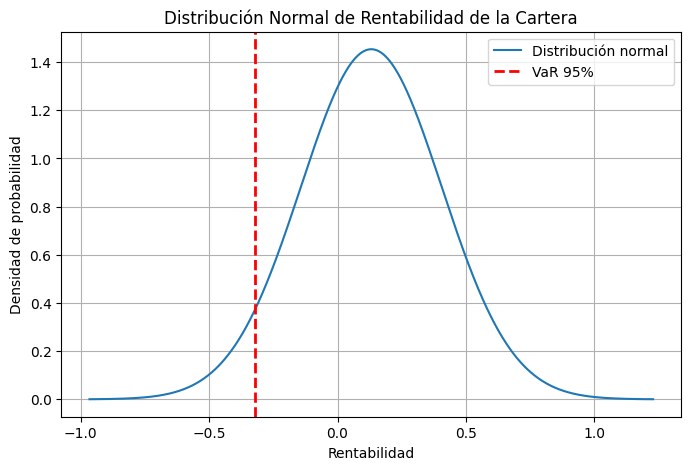

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Tus valores calculados
mean = rentabilidad_cartera_anual
std = volatilidad_cartera_anual

# Rango de valores de x
x = np.linspace(mean - 4*std, mean + 4*std, 1000)
pdf = norm.pdf(x, loc=mean, scale=std)

# Calcular el umbral del 95%
max_95 = mean + norm.ppf(0.05) * std

# Graficar distribución y línea VaR 95%
plt.figure(figsize=(8, 5))
plt.plot(x, pdf, label='Distribución normal')
plt.axvline(max_95, color='red', linestyle='--', linewidth=2, label='VaR 95%')
plt.title('Distribución Normal de Rentabilidad de la Cartera')
plt.xlabel('Rentabilidad')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.grid(True)
plt.show()

También nos interesa saber la curtosis y la simetría de los retornos. Abajo te dejo el análisis.

In [71]:
retornos_cartera=pd.DataFrame(retornos_cartera)
stats_portfolio=[retornos_cartera.skew(),retornos_cartera.kurtosis()]
print(f'Value of skewness is:', round(stats_portfolio[0].iloc[0],4))
print(f'Value of kurtosis is:', round(stats_portfolio[1].iloc[0],4))

Value of skewness is: -1.1045
Value of kurtosis is: 8.2986


En contexto financiero, un valor de skewness (asimetría) de -1.1045 indica que la distribución de los retornos es asimétrica hacia la izquierda, es decir, existen más probabilidad de rendimientos negativos extremos que positivos (colas más largas hacia pérdidas). Esto implica riesgo de sufrir caídas severas ocasionales dentro de la serie de rendimientos de la cartera, aunque la mayoría del tiempo los rendimientos puedan ser pequeños o positivos.

El valor de kurtosis de 8.2986 es muy superior al promedio de una distribución normal (que es 3), lo que implica la presencia de “colas gruesas”. Esto significa que los rendimientos extremos (tanto pérdidas como ganancias muy fuertes) son mucho más probables de lo que predeciría una distribución normal.



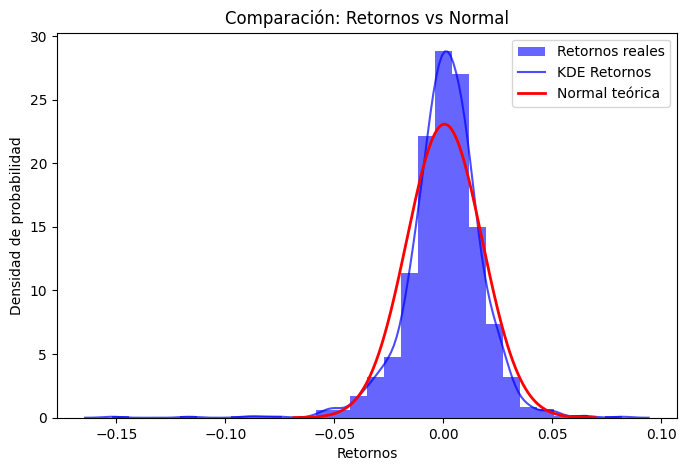

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Si tu DataFrame es una sola columna:
datos = retornos_cartera.iloc[:,0]

# Estimar parámetros
mean = datos.mean()
std = datos.std()

# Graficar histograma o KDE de tus datos reales
plt.figure(figsize=(8,5))
plt.hist(datos, bins=30, density=True, alpha=0.6, color='blue', label='Retornos reales')

# También puedes usar KDE para más suavidad:
import seaborn as sns
sns.kdeplot(datos, color="blue", label='KDE Retornos', alpha=0.7)

# Sobreponer la curva normal teórica con los parámetros estimados:
x = np.linspace(mean - 4*std, mean + 4*std, 1000)
plt.plot(x, norm.pdf(x, mean, std), color='red', linewidth=2, label='Normal teórica')

plt.title("Comparación: Retornos vs Normal")
plt.xlabel("Retornos")
plt.ylabel("Densidad de probabilidad")
plt.legend()
plt.show()

##Cuarta Parte

En esta última parte vamos a hacer algo intersante. Vamos a suponer que un cliente no quiere más de un 25%. ¿Cómo se deben ajustar los pesos?

In [73]:
import cvxpy as cp

# Riesgo máximo anual (25%)
riesgo_obj = 0.25
num_act = len(portfolio_weights)
pesos1 = cp.Variable(num_act)
# Rentabilidad esperada anual (asegúrate que rentabilidad_cartera_activos también esté anualizada)
rentabilidad = cp.Maximize(rentabilidad_cartera_activos.values.T @ pesos1)
matriz_cov_anual = matriz_cov * 252
# Riesgo = varianza anualizada
riesgo = cp.quad_form(pesos1, matriz_cov_anual)
constraints = [
    cp.sum(pesos1) == 1,
    pesos1 >= 0,
    riesgo <= riesgo_obj**2   # comparación en términos de varianza anual
]
prob = cp.Problem(rentabilidad, constraints)
resultado = prob.solve(solver=cp.CLARABEL)


In [74]:
# Rentabilidad óptima de la cartera
print("Rentabilidad óptima esperada de la cartera:", round(rentabilidad.value*252,4)*100, '%')

# Pesos óptimos de inversión
print("\nPesos óptimos de inversión por activo:")
for asset, weight in zip(rentabilidad_cartera_activos.index, pesos1.value):
    print(f"{asset}: {weight:.4f}")

# Riesgo de la cartera resultante
riesgo_resultado = (pesos1.value.T @ matriz_cov*252 @ pesos1.value) ** 0.5
print("\nVolatilidad (riesgo) de la cartera resultante:", round(riesgo_resultado,10)*100,'%')

Rentabilidad óptima esperada de la cartera: 24.77 %

Pesos óptimos de inversión por activo:
AGG: 0.0000
ARKK: 0.0000
EWZ: 0.0000
IAU: 0.5566
IWM: 0.0000
META: 0.0341
NFLX: 0.0000
TSLA: 0.3001
XLK: 0.1092
XLU: 0.0000

Volatilidad (riesgo) de la cartera resultante: 24.999986709999998 %


Ahora vamos a calcualr la cartera con la que podamos lograr la mayor rentabilidad.

**Nota: No apto para personas con problemas cardiácos.**

In [75]:
rentabilidad = cp.Maximize(rentabilidad_cartera_activos.values.T @ pesos1)
import cvxpy as cp

num_act = len(rentabilidad_cartera_activos)

# Variables (pesos de la cartera)
pesos2 = cp.Variable(num_act)

# Objetivo: maximizar la rentabilidad esperada
rentabilidad_max = cp.Maximize(rentabilidad_cartera_activos.values.T @ pesos2)

# Restricciones: suma de pesos = 1, sin cortos
constraints = [
    cp.sum(pesos2) == 1,
    pesos2 >= 0
]

# Definir problema
prob_max_rent = cp.Problem(rentabilidad_max, constraints)

# Resolver
resultado_max_rent = prob_max_rent.solve(solver=cp.CLARABEL)

# ------------------------
# Resultados
# ------------------------
# Rentabilidad anualizada
rentabilidad_optima = rentabilidad_max.value * 252 * 100
print("Rentabilidad máxima esperada de la cartera: {:.2f}%".format(rentabilidad_optima))

# Pesos óptimos
print("\nPesos óptimos de inversión por activo:")
for asset, weight in zip(rentabilidad_cartera_activos.index, pesos2.value):
    print(f"{asset}: {weight*100:.2f}%")

# Riesgo asociado (volatilidad anualizada)
riesgo_resultado = (pesos2.value.T @ (matriz_cov * 252) @ pesos2.value) ** 0.5
print("\nVolatilidad (riesgo) de la cartera resultante: {:.2f}%".format(riesgo_resultado * 100))


Rentabilidad máxima esperada de la cartera: 53.73%

Pesos óptimos de inversión por activo:
AGG: 0.00%
ARKK: 0.00%
EWZ: 0.00%
IAU: 0.00%
IWM: 0.00%
META: 0.00%
NFLX: 0.00%
TSLA: 100.00%
XLK: 0.00%
XLU: 0.00%

Volatilidad (riesgo) de la cartera resultante: 67.01%


Parece obvio, ¿verdad? ¿Recuerdas el gráfico?

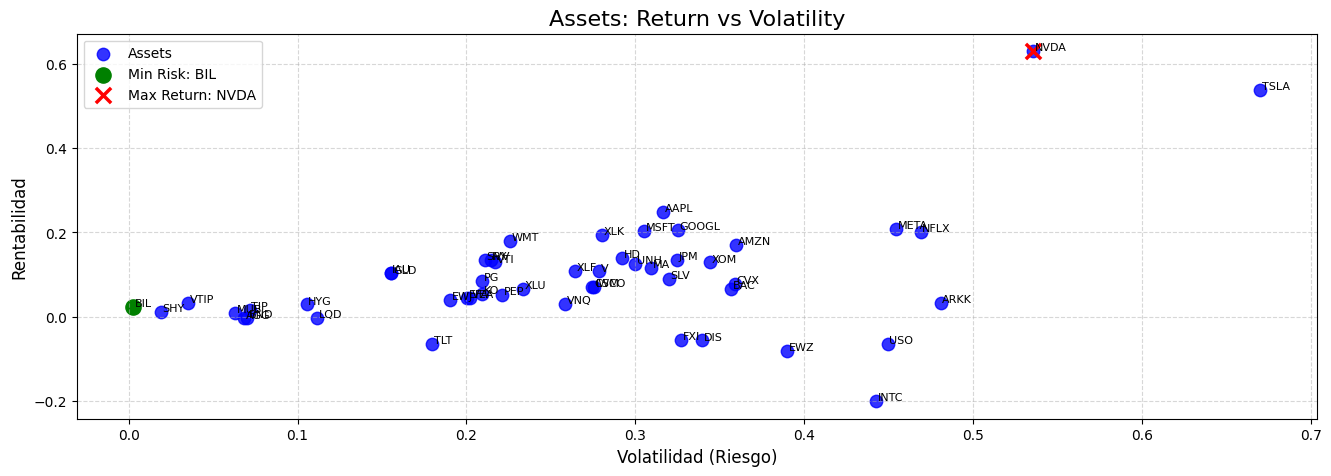

In [76]:
plt.figure(figsize=(16,5))

# Puntos de los activos
plt.scatter(volatilidad_universe, rentabilidad_universe, color='blue', s=80, alpha=0.8, label="Assets")

# Añadir etiquetas de cada activo
for asset in volatilidad_universe.index:
    plt.text(volatilidad_universe[asset] + 0.001,
             rentabilidad_universe[asset] + 0.001,
             asset, fontsize=8)

# Activo de menor riesgo
min_vol = volatilidad_universe.min()
asset_min_vol = volatilidad_universe.idxmin()
plt.scatter(min_vol, rentabilidad_universe[asset_min_vol], color='green', s=120, marker='o', label=f'Min Risk: {asset_min_vol}')

# Activo más rentable
max_ret = rentabilidad_universe.max()
asset_max_ret = rentabilidad_universe.idxmax()
plt.scatter(volatilidad_universe[asset_max_ret], max_ret, color='red', s=120, marker='x', linewidths=2.5, label=f'Max Return: {asset_max_ret}')

# Etiquetas y estilo
plt.title('Assets: Return vs Volatility', fontsize=16)
plt.xlabel('Volatilidad (Riesgo)', fontsize=12)
plt.ylabel('Rentabilidad', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Hago lo mismo para mínima volatilidad


In [77]:
import cvxpy as cp

num_act = len(rentabilidad_cartera_activos)

# Variables (pesos de la cartera)
pesos_min_var = cp.Variable(num_act)

# Función objetivo: minimizar la varianza anualizada
riesgo_min = cp.Minimize(cp.quad_form(pesos_min_var, matriz_cov * 252))

# Restricciones: suma de pesos = 1, sin cortos
constraints = [
    cp.sum(pesos_min_var) == 1,
    pesos_min_var >= 0
]

# Definir problema
prob_min_var = cp.Problem(riesgo_min, constraints)

# Resolver
resultado_min_var = prob_min_var.solve(solver=cp.CLARABEL)

# ------------------------
# Resultados
# ------------------------
# Riesgo mínimo (desviación estándar anual)
riesgo_optimo = (pesos_min_var.value.T @ (matriz_cov * 252) @ pesos_min_var.value) ** 0.5
print("Volatilidad mínima de la cartera: {:.2f}%".format(riesgo_optimo * 100))

# Rentabilidad esperada anualizada
rentabilidad_optima = (rentabilidad_cartera_activos.values.T @ pesos_min_var.value) * 252 * 100
print("Rentabilidad esperada de la cartera de mínima volatilidad: {:.2f}%".format(rentabilidad_optima))

# Pesos óptimos
print("\nPesos óptimos de inversión por activo:")
for asset, weight in zip(rentabilidad_cartera_activos.index, pesos_min_var.value):
    print(f"{asset}: {weight*100:.2f}%")


Volatilidad mínima de la cartera: 6.80%
Rentabilidad esperada de la cartera de mínima volatilidad: 0.29%

Pesos óptimos de inversión por activo:
AGG: 93.89%
ARKK: 0.00%
EWZ: 0.00%
IAU: 3.08%
IWM: 0.00%
META: 0.00%
NFLX: 0.00%
TSLA: 0.00%
XLK: 0.92%
XLU: 2.12%


###Espero que te hayan servido estas explicaciones sobre rentabilidad-riesgo y te ayude con tus finanzas.